# INP浓度的时间序列

在一张图上用不同颜色绘制各个温度的INP浓度(月均, 周均, 日均, 原始), errorbar用`median + IQR`表示

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy.optimize import curve_fit

In [2]:
df = pd.read_csv(r"D:\Coding\Data\Lanzhou_cfdc\processed\N_INP(202409-202509)v2.3.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')

In [3]:
def is_extreme(series):
    lower_bound = series.quantile(0.01)
    upper_bound = series.quantile(0.99)
    return (series < lower_bound) | (series > upper_bound)

In [4]:
def is_outlier(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 3 * iqr
    upper_bound = q3 + 3 * iqr
    return (series < lower_bound) | (series > upper_bound)

## 月均INP浓度

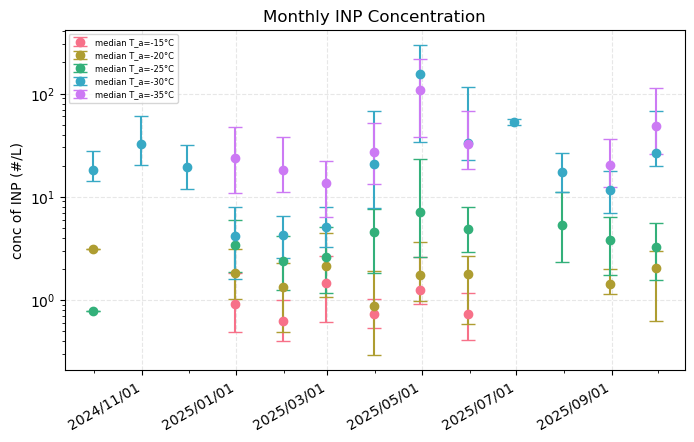

In [5]:
# 在一张图上用不同颜色绘制各个温度的INP浓度(月均), bar用IQR表示

TEMPERATURE = [-15, -20, -25, -30, -35]
colors = sns.color_palette("husl", len(TEMPERATURE))
fig, ax = plt.subplots(figsize=(8, 5))
for i, temp in enumerate(TEMPERATURE):
    # 数据质控
    df_temp = df[df['T_a(°C)'] == temp]

    conc_inp = df_temp['N_inp_net(#/L)']
    conc_inp_month = conc_inp.resample('ME').mean()
    conc_inp_month_median = conc_inp.resample('ME').median()
    q1 = conc_inp.resample('ME').quantile(0.25)
    q3 = conc_inp.resample('ME').quantile(0.75)
    lower_error = conc_inp_month_median - q1
    upper_error = q3 - conc_inp_month_median

    ax.errorbar(conc_inp_month_median.index, conc_inp_month_median.values,
                yerr=[lower_error, upper_error], fmt='o', color=colors[i], capsize=5, label=f'median T_a={temp}°C', zorder=10)# 使用1/4分位数和3/4分位数作为标准差

ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y/%m/%d"))
fig.autofmt_xdate()   # 自动旋转日期标签

ax.set_ylabel('conc of INP (#/L)')
ax.set_yscale('log')

ax.set_title('Monthly INP Concentration')
ax.grid(alpha=0.3, linestyle='--')
ax.legend(fontsize=6)

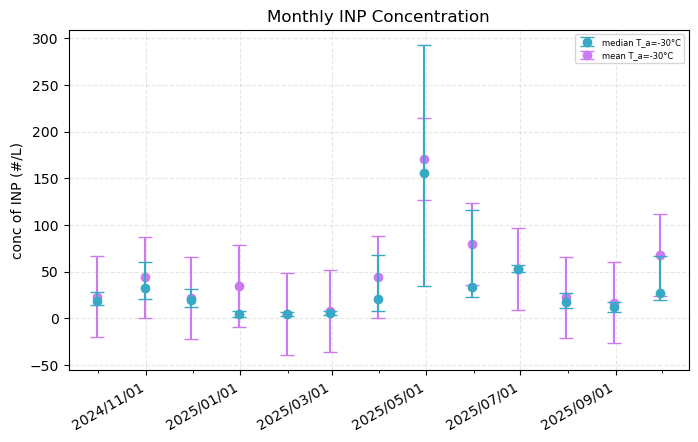

In [6]:
# 月均INP浓度, errorbar分别用`mean + std`和`median + IQR`表示, 对比差异

TEMPERATURE = [-15, -20, -25, -30, -35]
colors = sns.color_palette("husl", len(TEMPERATURE))
fig, ax = plt.subplots(figsize=(8, 5))
for i, temp in enumerate(TEMPERATURE):
    df_temp = df[df['T_a(°C)'] == temp]

    conc_inp = df_temp['N_inp_net(#/L)']
    conc_inp_month = conc_inp.resample('ME').mean()
    conc_inp_month_median = conc_inp.resample('ME').median()
    q1 = conc_inp.resample('ME').quantile(0.25)
    q3 = conc_inp.resample('ME').quantile(0.75)
    lower_error = conc_inp_month_median - q1
    upper_error = q3 - conc_inp_month_median

    if temp == -30:
        ax.errorbar(conc_inp_month_median.index, conc_inp_month_median.values,
                yerr=[lower_error, upper_error], fmt='o', color=colors[i], capsize=5, label=f'median T_a={temp}°C', zorder=10)# 使用1/4分位数和3/4分位数作为标准差
        ax.errorbar(conc_inp_month.index, conc_inp_month.values,
                yerr=conc_inp_month.std(), fmt='o', color=colors[i+1], capsize=5, label=f'mean T_a={temp}°C')
    
    
#ax.xaxis.set_major_locator(mdates.DayLocator(interval=15))
ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y/%m/%d"))
fig.autofmt_xdate()   # 自动旋转日期标签

ax.set_ylabel('conc of INP (#/L)')
#ax.set_yscale('log')

ax.set_title('Monthly INP Concentration')
ax.grid(alpha=0.3, linestyle='--')
ax.legend(fontsize=6)

## 周均INP浓度

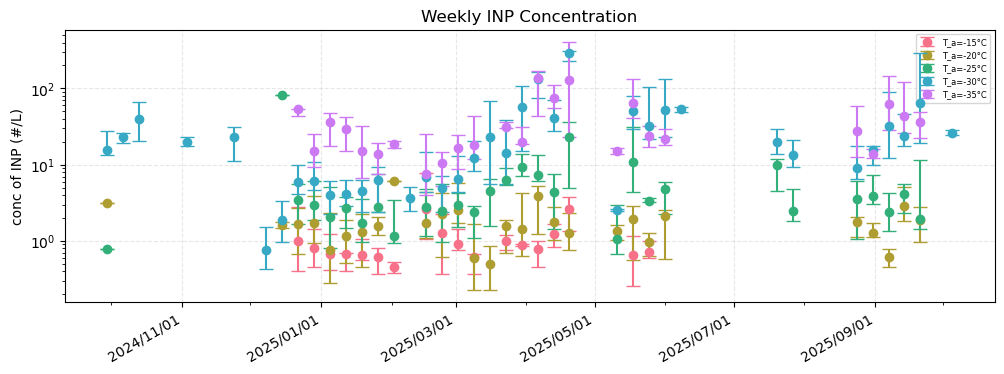

In [7]:
# 在一张图上用不同颜色绘制各个温度的INP浓度(周均), bar用IQR表示

TEMPERATURE = [-15, -20, -25, -30, -35]
colors = sns.color_palette("husl", len(TEMPERATURE))
fig, ax = plt.subplots(figsize=(12, 4))
for i, temp in enumerate(TEMPERATURE):
    df_temp = df[df['T_a(°C)'] == temp]

    conc_inp = df_temp['N_inp_net(#/L)']
    conc_inp_week = conc_inp.resample('W').mean()
    conc_inp_week_median = conc_inp.resample('W').median()
    q1 = conc_inp.resample('W').quantile(0.25)
    q3 = conc_inp.resample('W').quantile(0.75)
    lower_error = conc_inp_week_median - q1
    upper_error = q3 - conc_inp_week_median

    ax.errorbar(conc_inp_week_median.index, conc_inp_week_median.values,
                yerr=[lower_error, upper_error], fmt='o', color=colors[i], capsize=5, label=f'T_a={temp}°C', zorder=10)# 使用1/4分位数和3/4分位数作为标准差

ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y/%m/%d"))
fig.autofmt_xdate()   # 自动旋转日期标签

ax.set_ylabel('conc of INP (#/L)')
ax.set_yscale('log')

ax.set_title('Weekly INP Concentration')
ax.grid(alpha=0.3, linestyle='--')
ax.legend(fontsize=6)

## 日均INP浓度

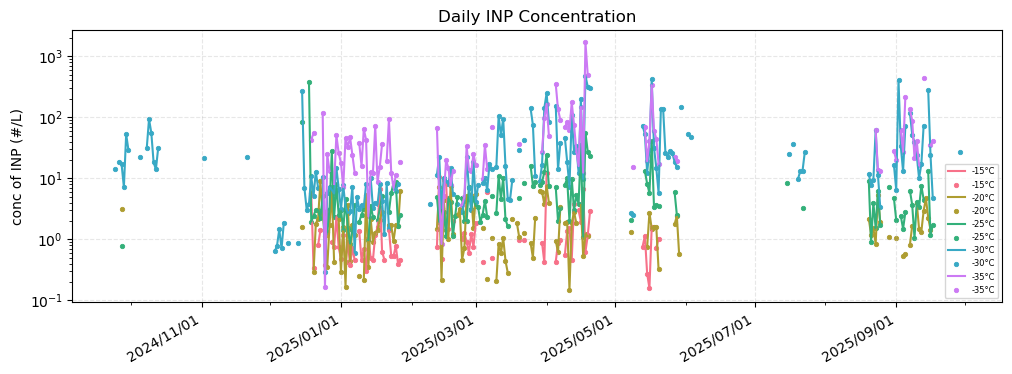

In [8]:
# 在一张图上用不同颜色绘制各个温度的INP浓度(日均), 未画误差bar(考虑到1.一个点的数据量较少;2.图片的清晰性)

TEMPERATURE = [-15, -20, -25, -30, -35]
colors = sns.color_palette("husl", len(TEMPERATURE))
fig, ax = plt.subplots(figsize=(12, 4))
for i, temp in enumerate(TEMPERATURE):
    df_temp = df[df['T_a(°C)'] == temp]

    conc_inp = df_temp['N_inp_net(#/L)']
    conc_inp_day = conc_inp.resample('D').mean()
    conc_inp_day_median = conc_inp.resample('D').median()
    q1 = conc_inp.resample('D').quantile(0.25)
    q3 = conc_inp.resample('D').quantile(0.75)
    lower_error = conc_inp_day_median - q1
    upper_error = q3 - conc_inp_day_median

    ax.plot(conc_inp_day.index, conc_inp_day.values, color=colors[i], label=f'{temp}°C') # 折线图
    ax.scatter(conc_inp_day.index, conc_inp_day.values, color=colors[i], s=10,label=f'{temp}°C', linewidth=0.6) # 散点图

ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y/%m/%d"))
fig.autofmt_xdate()   # 自动旋转日期标签

ax.set_ylabel('conc of INP (#/L)')
ax.set_yscale('log')

ax.set_title('Daily INP Concentration')
ax.grid(alpha=0.3, linestyle='--')
ax.legend(fontsize=6)

## 原始INP浓度(次日级)

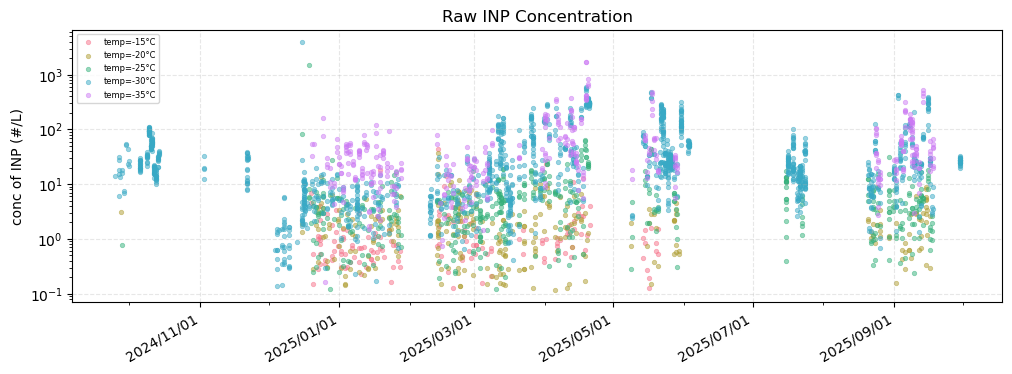

In [9]:
# 在一张图上用不同颜色绘制各个温度的INP浓度(原始)

TEMPERATURE = [-15, -20, -25, -30, -35]
colors = sns.color_palette("husl", len(TEMPERATURE))
fig, ax = plt.subplots(figsize=(12, 4))
for i, temp in enumerate(TEMPERATURE):
    df_temp = df[df['T_a(°C)'] == temp]

    conc_inp = df_temp['N_inp_net(#/L)']
    ax.scatter(conc_inp.index, conc_inp.values, color=colors[i], s=10, alpha=0.5, label=f'temp={temp}°C', linewidth=0.6)


ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y/%m/%d"))
fig.autofmt_xdate()   # 自动旋转日期标签

ax.set_ylabel('conc of INP (#/L)')
ax.set_yscale('log')

ax.set_title('Raw INP Concentration')
ax.grid(alpha=0.3, linestyle='--')
ax.legend(fontsize=6)

## 草稿

In [10]:
# 给时间序列添加四季背景色
season_colors = {
    'Spring': 'lightskyblue',
    'Summer': 'lightgreen',
    'Autumn': 'moccasin',
    'Winter': 'lavender'
}
season_series = df_selected['season']
#print(season_series)
season_blocks = season_series.ne(season_series.shift()).cumsum()
#print(season_blocks)
#added_labels = set()
#for _, block in season_series.groupby(season_blocks):
#    start, end = block.index.min(), block.index.max()
#    season_name = block.iloc[0]
#    color = season_colors.get(season_name, 'lightgray')
#    #label = season_name if season_name not in added_labels else None
#    ax.axvspan(start, end, color=color, alpha=0.15)
#    #added_labels.add(season_name)

NameError: name 'df_selected' is not defined